# Imports

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import csv
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error,mean_absolute_error

# Load Data

## Sensors Data

In [6]:
from re import match
class Reader:

  def __init__(self, dir, encoding="ISO-8859-1"):
    data = []
    header = None
    measures = []
    with open(dir, 'r', encoding=encoding) as file:
      csvreader = csv.reader(file, dialect=csv.excel)
      for row in csvreader:
        values = ','.join(row)
        values = values.split(';')
        if values[0] == 'Date (MM/DD/YYYY)' and header == None:
          header = [x for x in values if x != '']
        elif match("\d{1,2}\/\d{1,2}\/\d{2,4}", values[0]):
          measures.append([x.replace(',', '.') for x in values if x != ''])
        elif len(measures) > 0:
          df = pd.DataFrame(data=measures, columns=header)
          df.set_index(header[0])
          data.append(df)
          header = None
          measures = []
    self.data = pd.concat(data, axis=0)
    self.data.reset_index(drop=True, inplace=True)

  def parse_data(self):
    self.data.insert(2, "DateTime", self.data[[self.data.columns[0], self.data.columns[1]]].agg(' '.join, axis=1))
    columns = self.data.columns
    self.data[columns[6:]] = self.data[columns[6:]].apply(pd.to_numeric, errors='coerce')
    self.data[columns[0]] = pd.to_datetime(self.data[columns[0]], dayfirst=True, format='%d/%m/%Y')
    self.data[columns[2]] = pd.to_datetime(self.data[columns[2]], dayfirst=True)
    datetime_utc = pd.to_datetime(self.data[columns[2]], dayfirst=True)
    datetime_utc = datetime_utc.dt.tz_localize("UTC").dt.tz_convert("Europe/Rome")
    self.data[columns[2]] = datetime_utc
    self.data[columns[3:5]] = self.data[columns[3:5]].apply(pd.to_numeric, errors='coerce')
    self.data[columns[5]] = self.data[columns[5]].astype('string')

In [7]:
reader = Reader('Fitterizzi_output.csv')
reader.parse_data()

## Weather Data

In [26]:
weather_data = pd.read_excel("Meteo Agosto 22 - Luglio 23.xlsx", sheet_name="Dati meteorologici")

In [27]:
weather_data["Data - ora"] = weather_data["Data - ora"].dt.tz_localize("UTC").dt.tz_convert("Europe/Rome")
weather_data.rename(columns={"Data - ora": "DateTime"}, inplace=True)

# Data to be Used

In [28]:
df = reader.data.copy()
df_weather = weather_data.copy()
print("Total sensor samples: ", len(df))
## using only data after 2022/07/01
df = df[df['DateTime'] > '2022-07-01 00:00:00']
print("Useful sensor samples: ", len(df))
print()
print("Total weather samples: ", len(df_weather))

Total sensor samples:  106660
Useful sensor samples:  41285

Total weather samples:  8736


In [10]:
df.columns

Index(['Date (MM/DD/YYYY)', 'Time (HH:mm:ss)', 'DateTime', 'Time (Fract',
       ' Sec)', 'Site Name', 'NH3 mg/L', 'Cond µS/cm', 'fDOM QSU',
       'NH4+ -N mV', 'fDOM RFU', 'NO3 -N mV', 'NO3 -N mg/L', 'nLF Cond µS/cm',
       'ODO % sat', 'ODO % local', 'ODO mg/L', 'NH4+ -N mg/L', 'ORP mV',
       'Sal psu', 'SpCond µS/cm', 'TDS mg/L', 'Turbidity FNU', 'TSS mg/L',
       'pH', 'pH mV', 'Temp °C', 'Battery V', 'Cable Pwr V',
       'Wiper Position volt'],
      dtype='object')

In [ ]:
df.head(10)

,Date (MM/DD/YYYY),Time (HH:mm:ss),DateTime,Time (Fract,Sec),Site Name,NH3 mg/L,Cond µS/cm,fDOM QSU,NH4+ -N mV,...,SpCond µS/cm,TDS mg/L,Turbidity FNU,TSS mg/L,pH,pH mV,Temp °C,Battery V,Cable Pwr V,Wiper Position volt
65375,2022-07-06,07:50:00,2022-07-06 09:50:00+02:00,0,0,Turbolo,NaN,10.0,-6.44,NaN,...,10.7,7,94.28,0.0,7.39,-473.4,21.337,6.00,0.0,1.091
65376,2022-07-06,08:00:00,2022-07-06 10:00:00+02:00,0,0,Turbolo,NaN,510.4,18.30,NaN,...,560.4,364,18.72,0.0,7.43,-475.1,20.336,5.96,0.0,0.773
65377,2022-07-06,08:10:00,2022-07-06 10:10:00+02:00,0,0,Turbolo,NaN,511.8,19.81,NaN,...,561.9,365,7.02,0.0,7.70,-488.7,20.332,5.91,0.0,0.704
65378,2022-07-06,08:20:00,2022-07-06 10:20:00+02:00,0,0,Turbolo,NaN,511.9,19.85,NaN,...,562.3,365,6.31,0.0,8.43,-525.7,20.307,5.97,0.0,0.690
65379,2022-07-06,08:30:00,2022-07-06 10:30:00+02:00,0,0,Turbolo,NaN,510.3,20.03,NaN,...,559.6,364,3.87,0.0,8.41,-524.7,20.381,5.99,0.0,0.690
65380,2022-07-06,08:40:00,2022-07-06 10:40:00+02:00,0,0,Turbolo,NaN,512.6,17.16,NaN,...,561.6,365,27.21,0.0,8.30,-519.2,20.429,5.99,0.0,0.690
65381,2022-07-06,08:50:00,2022-07-06 10:50:00+02:00,0,0,Turbolo,NaN,16.3,-6.42,NaN,...,17.7,12,25.00,0.0,8.51,-530.2,20.956,6.00,0.0,0.690
65382,2022-07-06,11:00:00,2022-07-06 13:00:00+02:00,0,0,Turbolo,NaN,3.9,-6.37,NaN,...,3.8,2,17.28,0.0,5.80,-391.9,26.161,5.96,0.0,0.683
65383,2022-07-06,11:10:00,2022-07-06 13:10:00+02:00,0,0,Turbolo,NaN,461.9,10.11,NaN,...,483.9,315,16.91,0.0,7.68,-488.2,22.625,5.95,0.0,1.081
65384,2022-07-06,11:20:00,2022-07-06 13:20:00+02:00,0,0,Turbolo,NaN,462.8,12.36,NaN,...,483.8,314,0.80,0.0,8.31,-520.3,22.732,5.99,0.0,0.831


# Missing Values

## Sensors Data

In [11]:
# print("summary:\n", df.describe())
print("\ncolumns:\n", df.columns)


columns:
 Index(['Date (MM/DD/YYYY)', 'Time (HH:mm:ss)', 'DateTime', 'Time (Fract',
       ' Sec)', 'Site Name', 'NH3 mg/L', 'Cond µS/cm', 'fDOM QSU',
       'NH4+ -N mV', 'fDOM RFU', 'NO3 -N mV', 'NO3 -N mg/L', 'nLF Cond µS/cm',
       'ODO % sat', 'ODO % local', 'ODO mg/L', 'NH4+ -N mg/L', 'ORP mV',
       'Sal psu', 'SpCond µS/cm', 'TDS mg/L', 'Turbidity FNU', 'TSS mg/L',
       'pH', 'pH mV', 'Temp °C', 'Battery V', 'Cable Pwr V',
       'Wiper Position volt'],
      dtype='object')


In [12]:
print("\ncolumns data types:\n", df.dtypes)


columns data types:
 Date (MM/DD/YYYY)                   datetime64[ns]
Time (HH:mm:ss)                             object
DateTime               datetime64[ns, Europe/Rome]
Time (Fract                                  int64
 Sec)                                        int64
Site Name                           string[python]
NH3 mg/L                                   float64
Cond µS/cm                                 float64
fDOM QSU                                   float64
NH4+ -N mV                                 float64
fDOM RFU                                   float64
NO3 -N mV                                  float64
NO3 -N mg/L                                float64
nLF Cond µS/cm                             float64
ODO % sat                                  float64
ODO % local                                float64
ODO mg/L                                   float64
NH4+ -N mg/L                               float64
ORP mV                                     float64
Sal psu  

In [13]:
print("\nnull values:\n", df.isna().sum())


null values:
 Date (MM/DD/YYYY)          0
Time (HH:mm:ss)            0
DateTime                   0
Time (Fract                0
 Sec)                      0
Site Name                  0
NH3 mg/L               20185
Cond µS/cm                 0
fDOM QSU                   0
NH4+ -N mV             20185
fDOM RFU                   0
NO3 -N mV              30008
NO3 -N mg/L            30008
nLF Cond µS/cm             0
ODO % sat              21100
ODO % local            21100
ODO mg/L               21100
NH4+ -N mg/L           20185
ORP mV                  2890
Sal psu                    0
SpCond µS/cm               0
TDS mg/L                   0
Turbidity FNU              0
TSS mg/L                   0
pH                      2890
pH mV                   2890
Temp °C                    0
Battery V                  0
Cable Pwr V                0
Wiper Position volt        0
dtype: int64


In [14]:
def plot_columns(dataframe, columns, highlight_missing=False, figsize=(20,30)):
  fig, ax = plt.subplots(len(columns), 1, figsize=figsize)
  fig.tight_layout()
  min_date = dataframe['DateTime'].min()
  max_date = dataframe['DateTime'].max()
  for i, col in enumerate(columns):
    x = dataframe['DateTime']
    if (highlight_missing == True):
      min = df_missing_data[col].min()
      not_valid = min - 0.00001
      values = df_missing_data[col]
      values_filled = df_missing_data[col].fillna(not_valid)
      not_null_values = np.ma.masked_where(values_filled > not_valid, values_filled)
      null_values = np.ma.masked_equal(values_filled, not_valid)
      ax[i].plot(x, null_values, x, not_null_values)
    else:
      values = dataframe[col]
      ax[i].plot(x, values)
    ax[i].set_ylabel(col)
    ax[i].set_xlim([min_date, max_date])
    ax[i].legend([col], labelcolor='red')

### Plot all Parameters

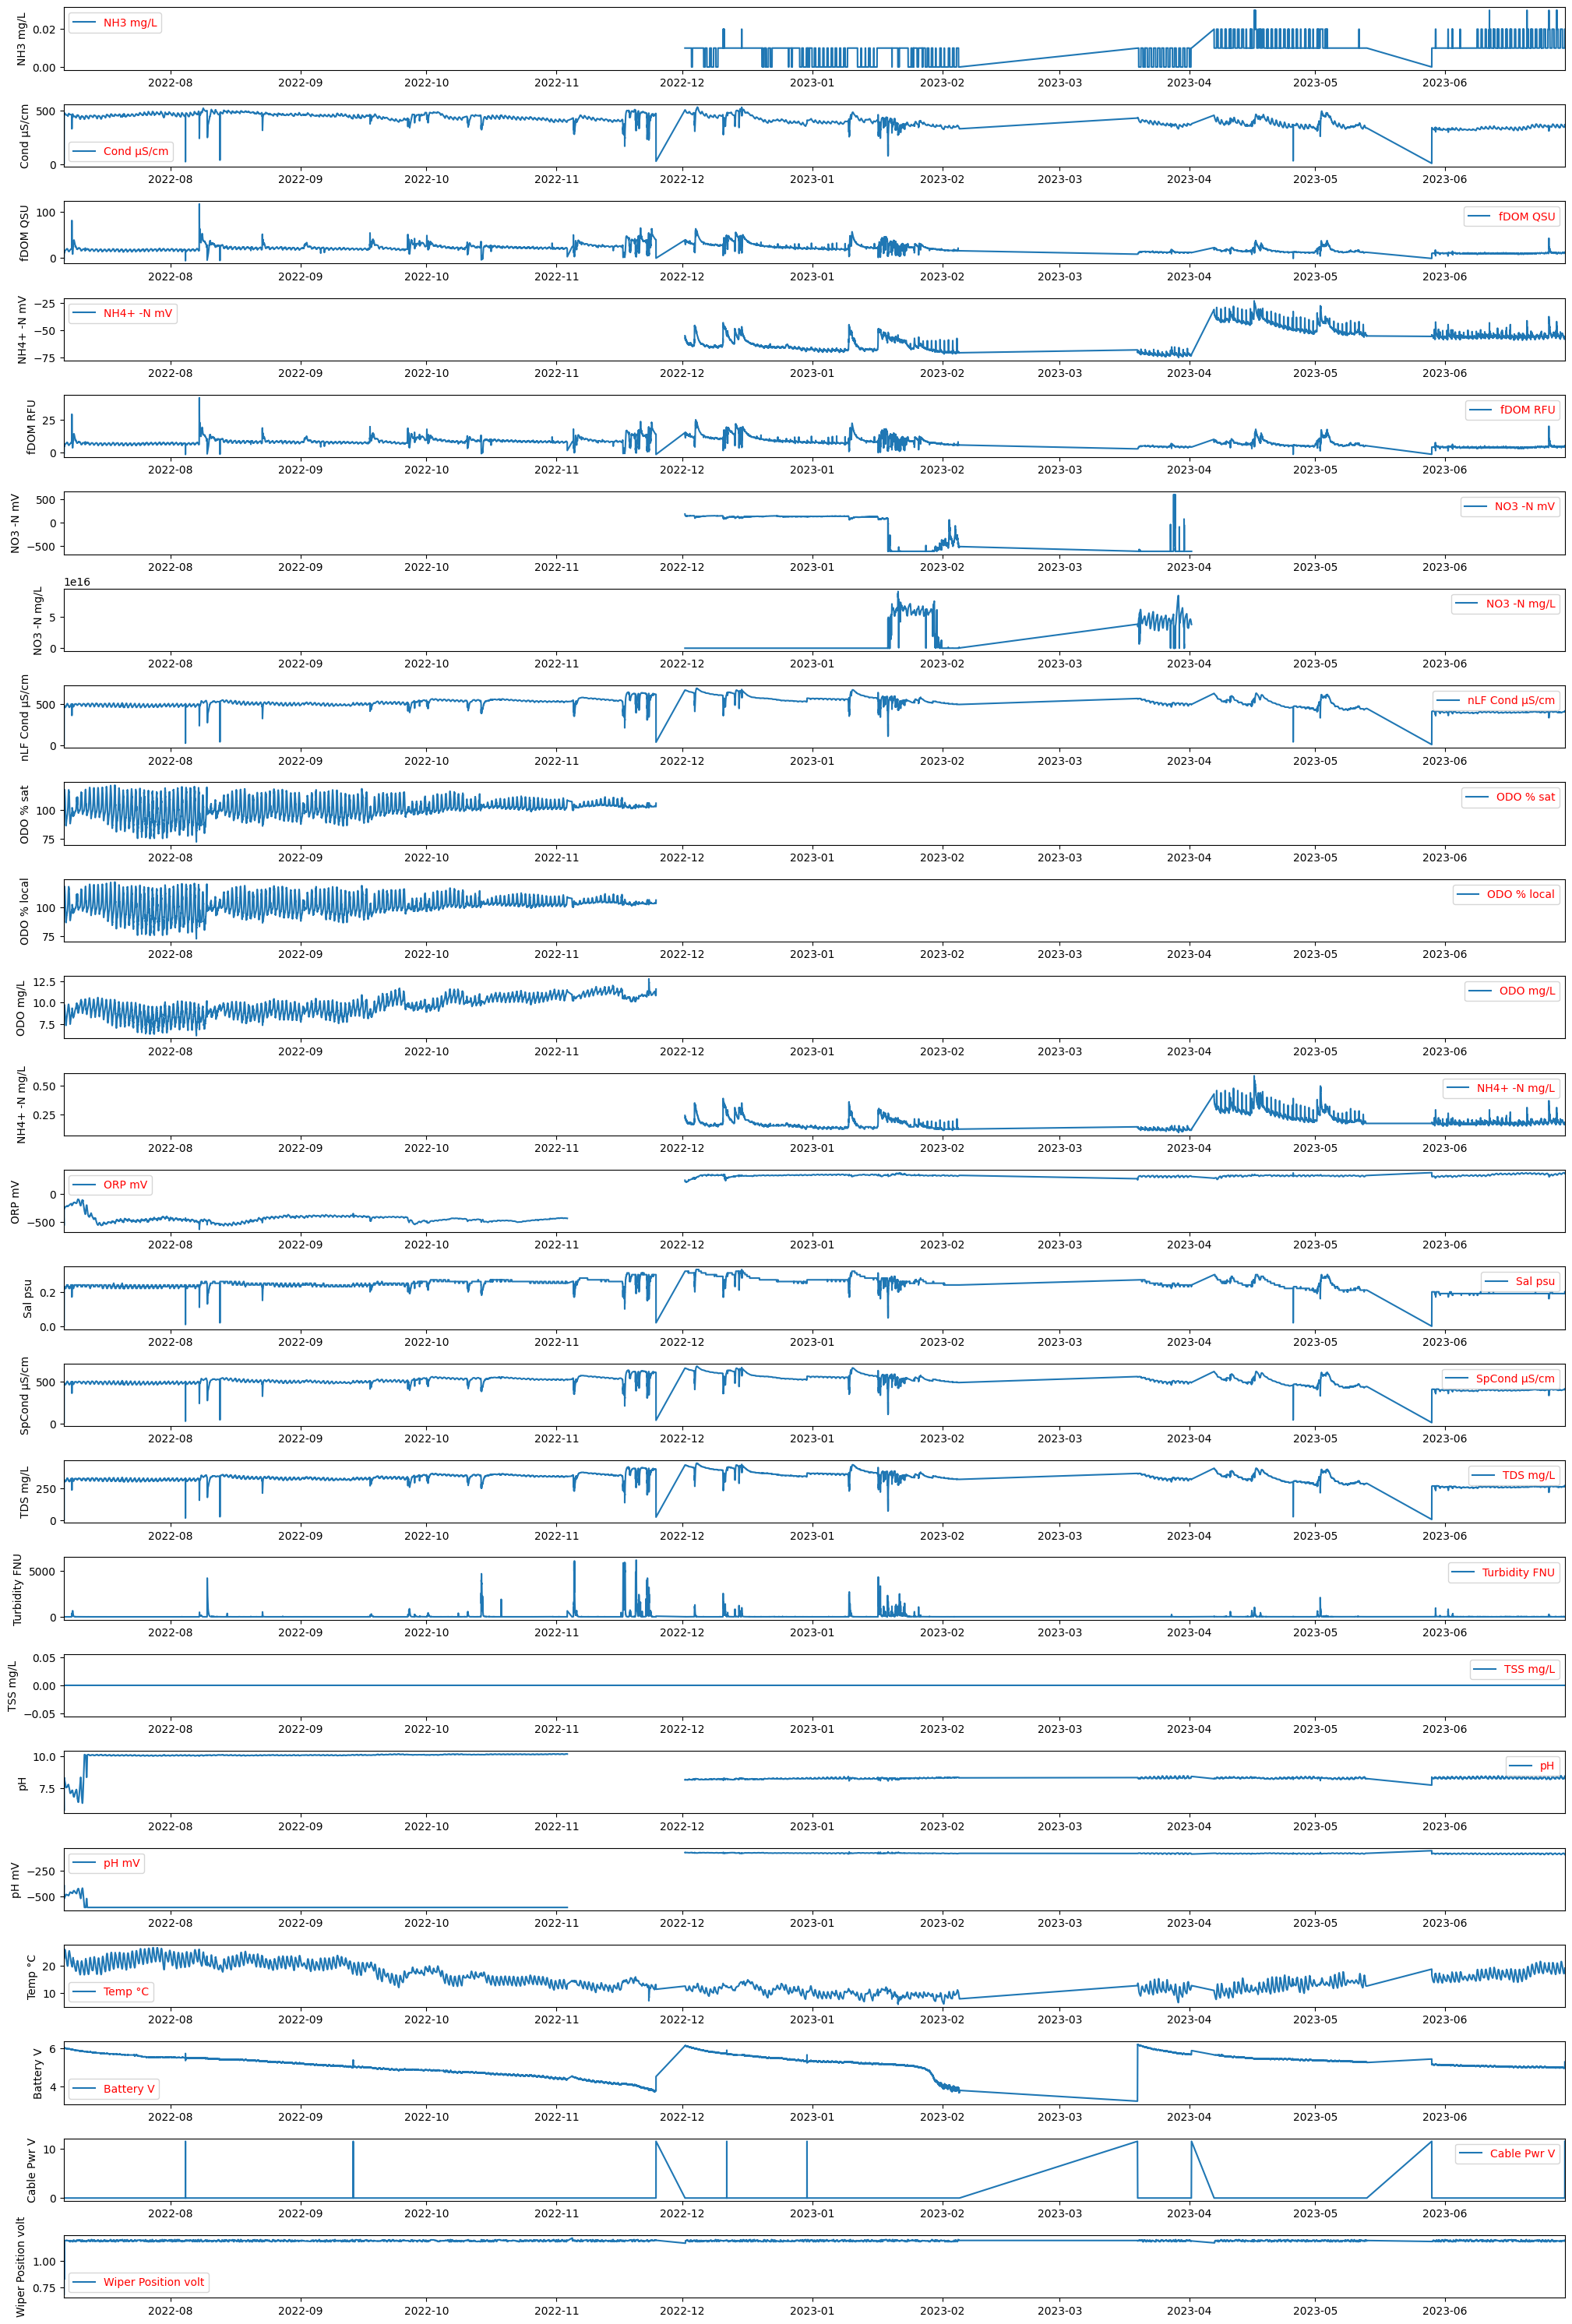

In [15]:
plot_columns(df, df.columns[6:])

In [16]:
df.columns

Index(['Date (MM/DD/YYYY)', 'Time (HH:mm:ss)', 'DateTime', 'Time (Fract',
       ' Sec)', 'Site Name', 'NH3 mg/L', 'Cond µS/cm', 'fDOM QSU',
       'NH4+ -N mV', 'fDOM RFU', 'NO3 -N mV', 'NO3 -N mg/L', 'nLF Cond µS/cm',
       'ODO % sat', 'ODO % local', 'ODO mg/L', 'NH4+ -N mg/L', 'ORP mV',
       'Sal psu', 'SpCond µS/cm', 'TDS mg/L', 'Turbidity FNU', 'TSS mg/L',
       'pH', 'pH mV', 'Temp °C', 'Battery V', 'Cable Pwr V',
       'Wiper Position volt'],
      dtype='object')

### Plot Parameters with missing values

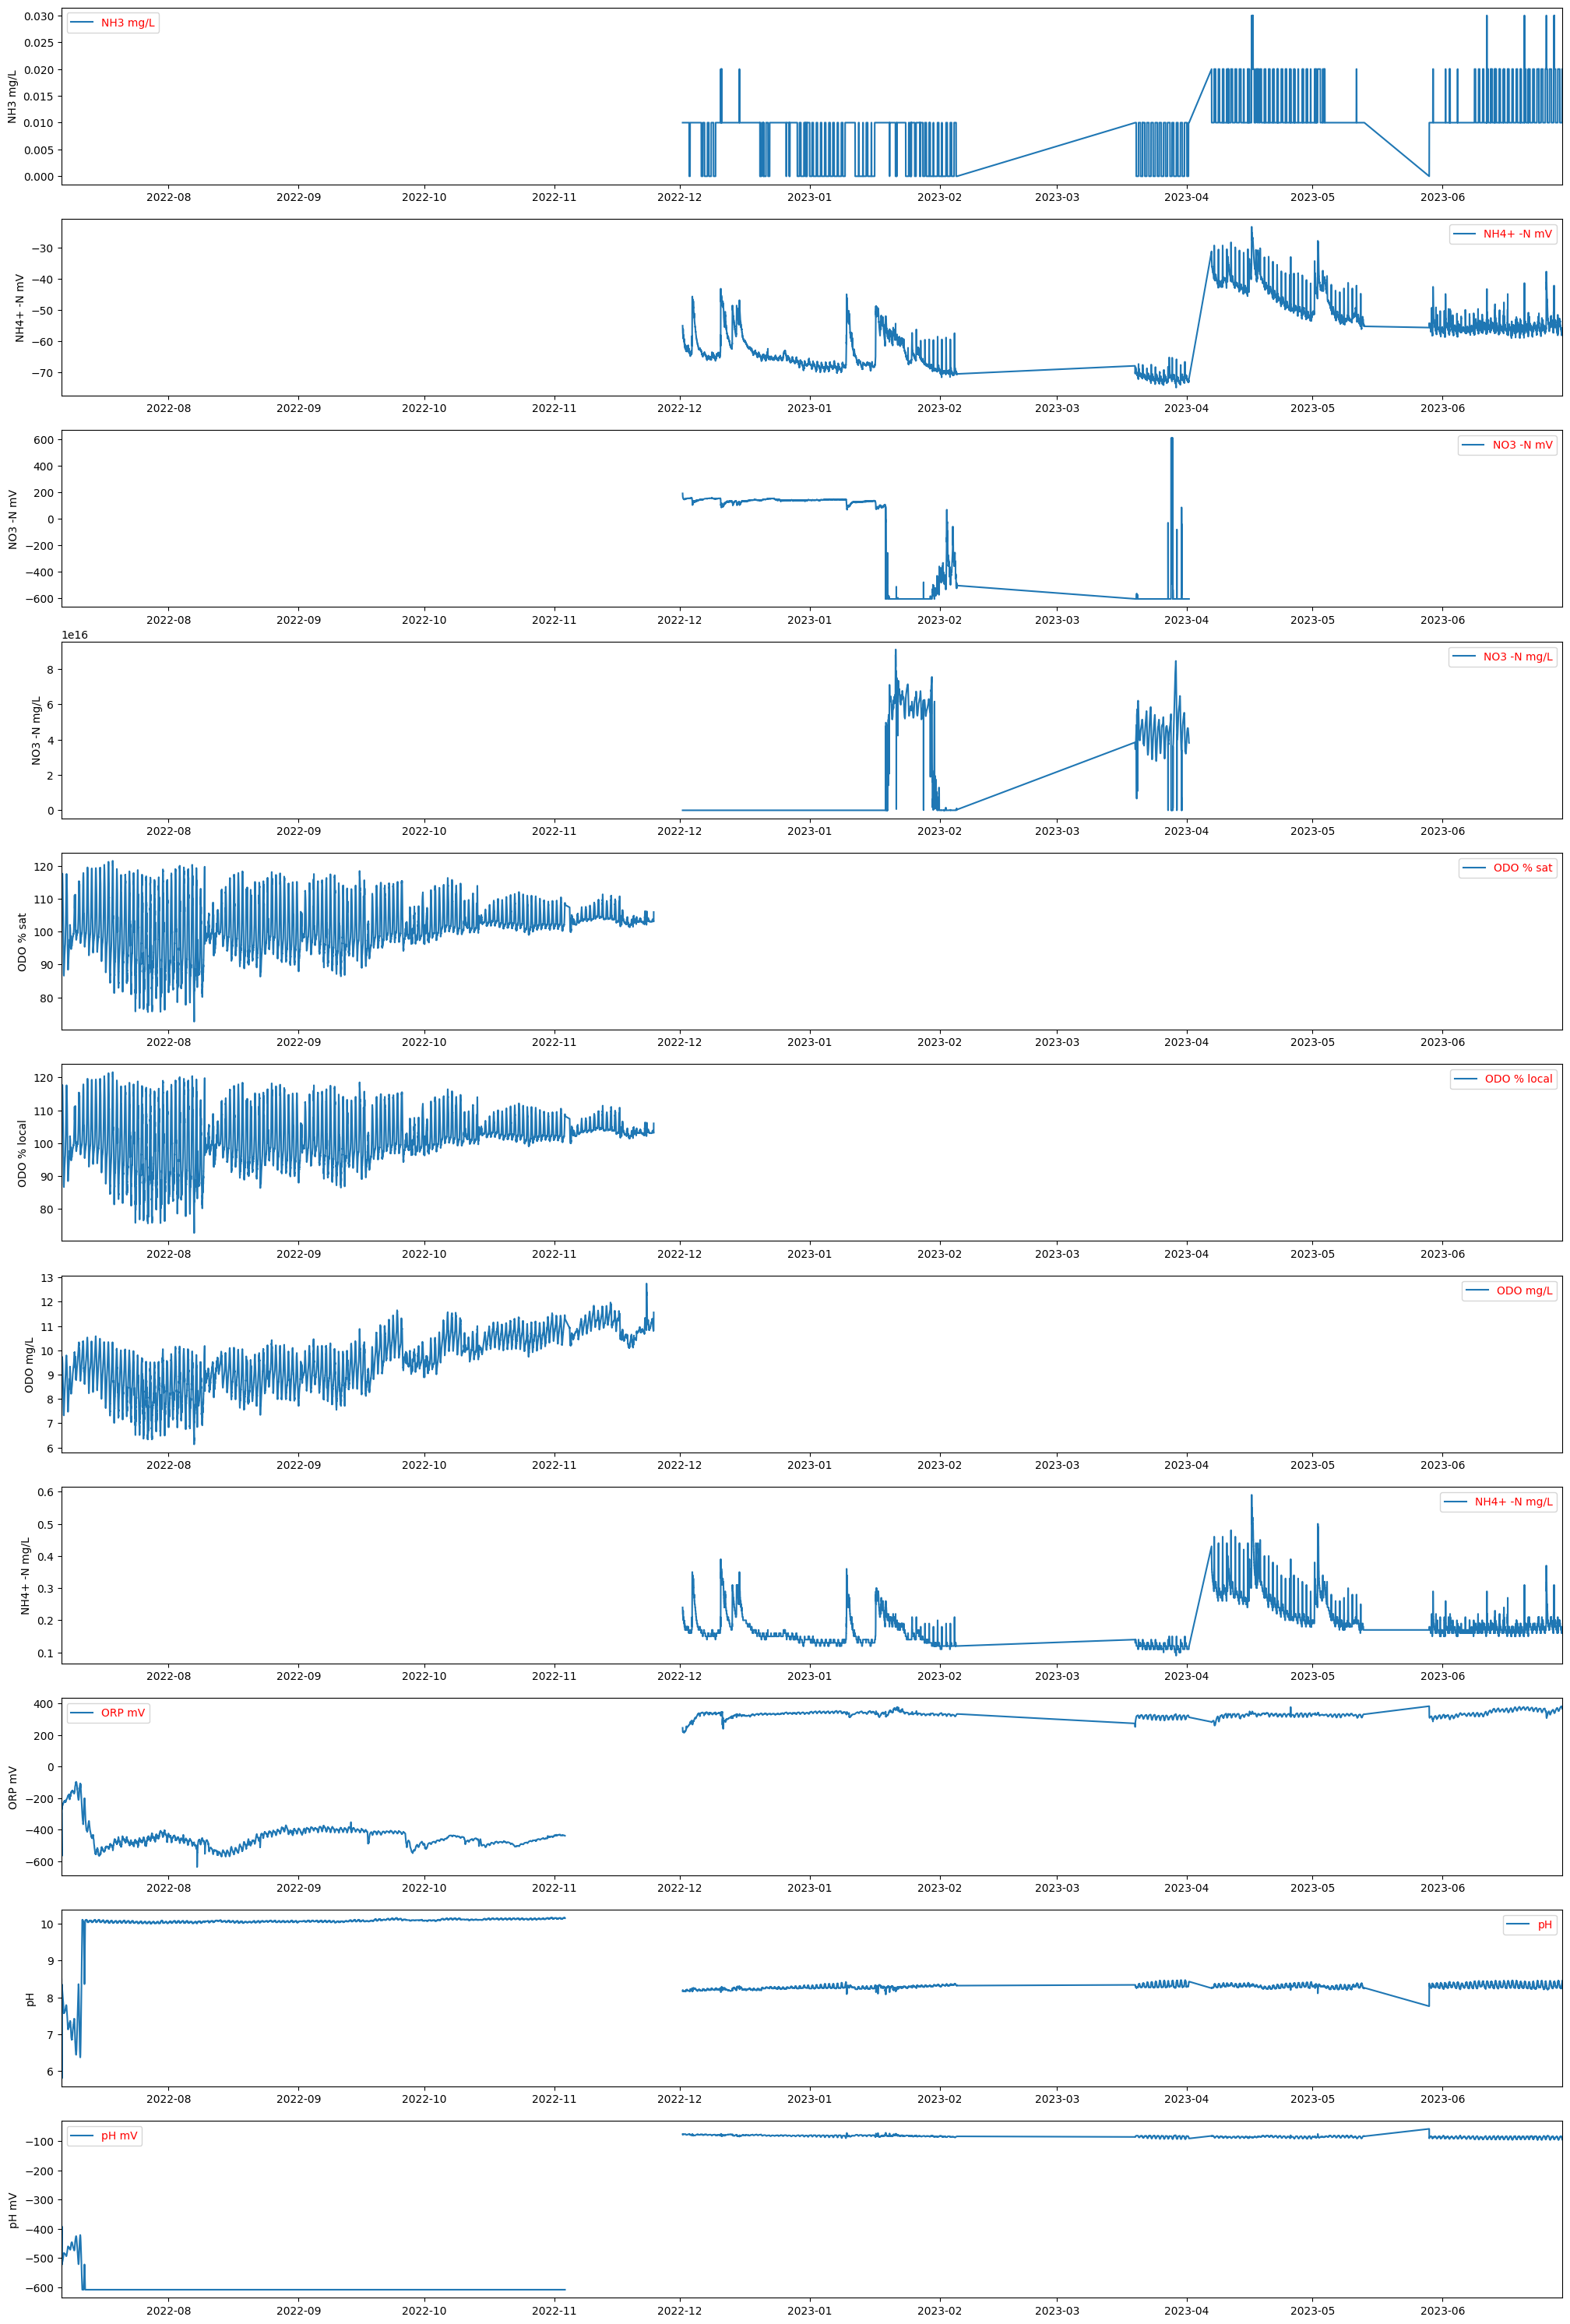

In [17]:
df_missing_data = df.copy()
columns_with_null = df_missing_data.columns[df_missing_data.isna().any()].tolist()
plot_columns(df_missing_data, columns_with_null)

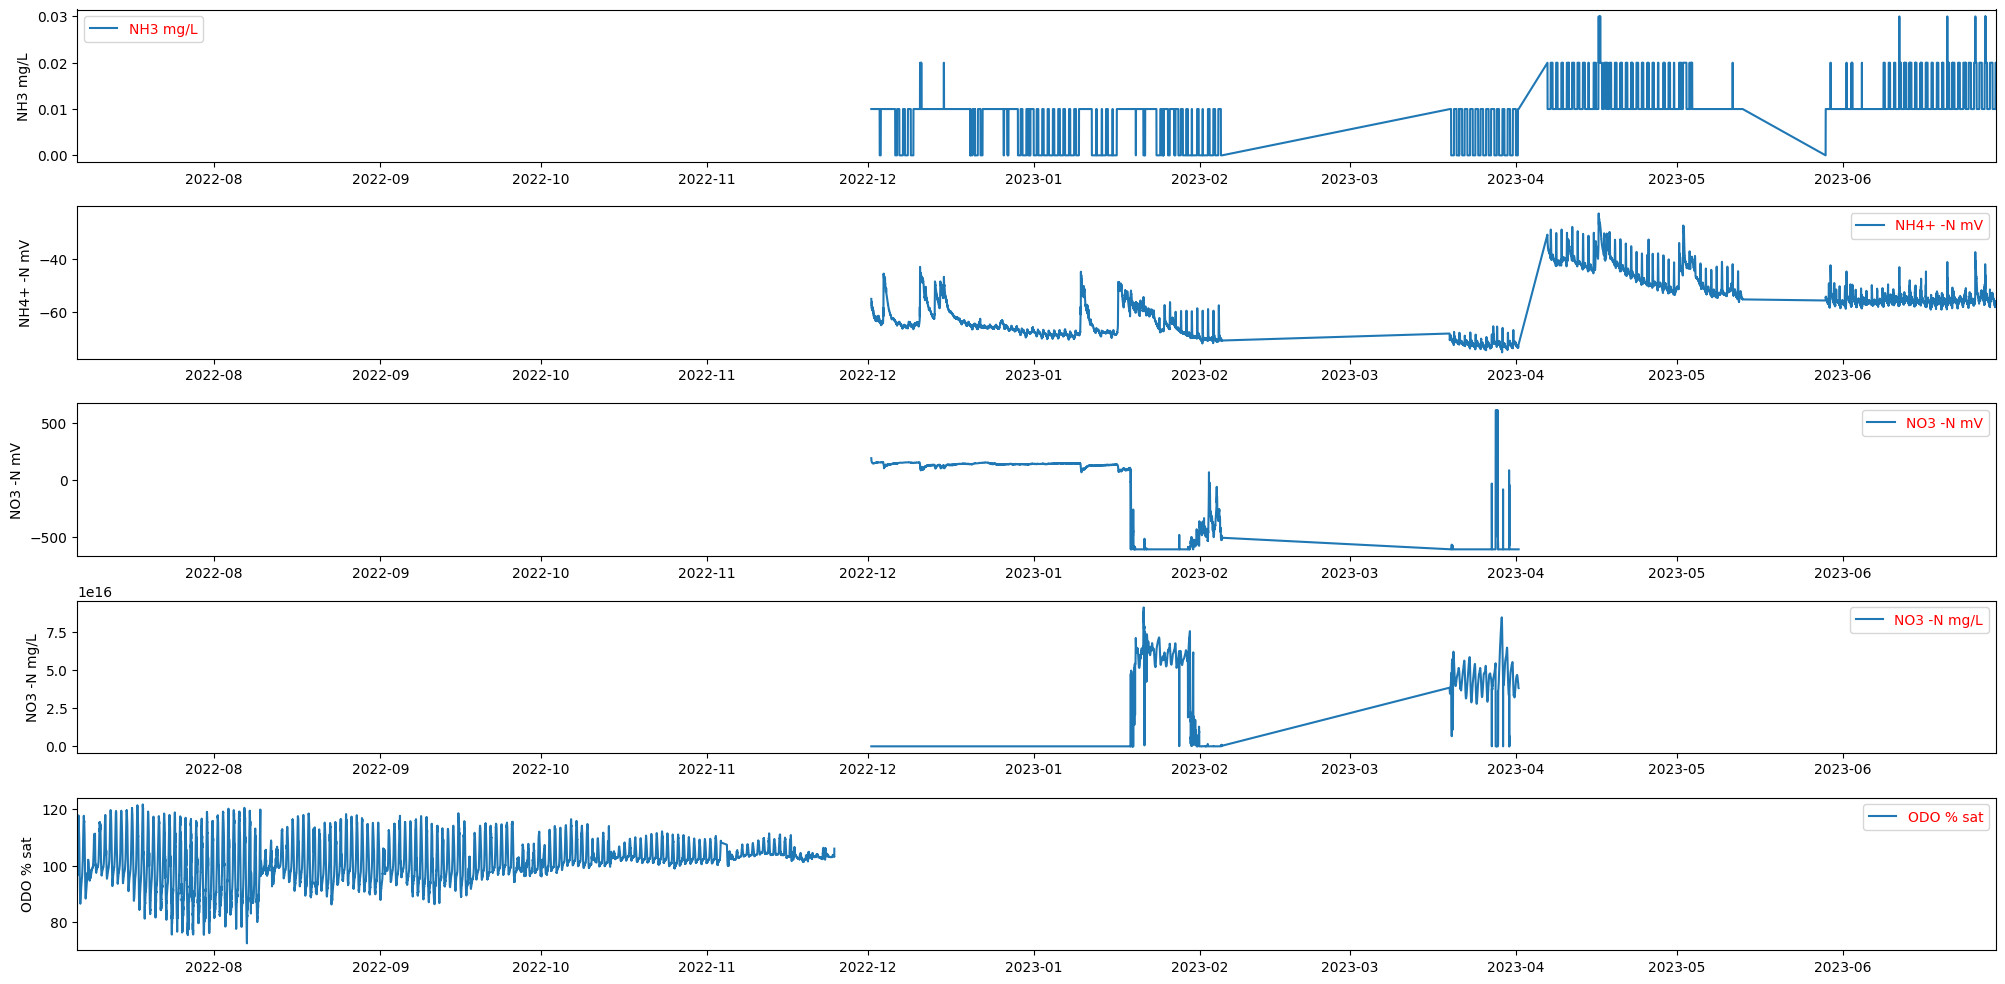

In [18]:
plot_columns(df_missing_data, columns_with_null[:5], figsize=(20,10))

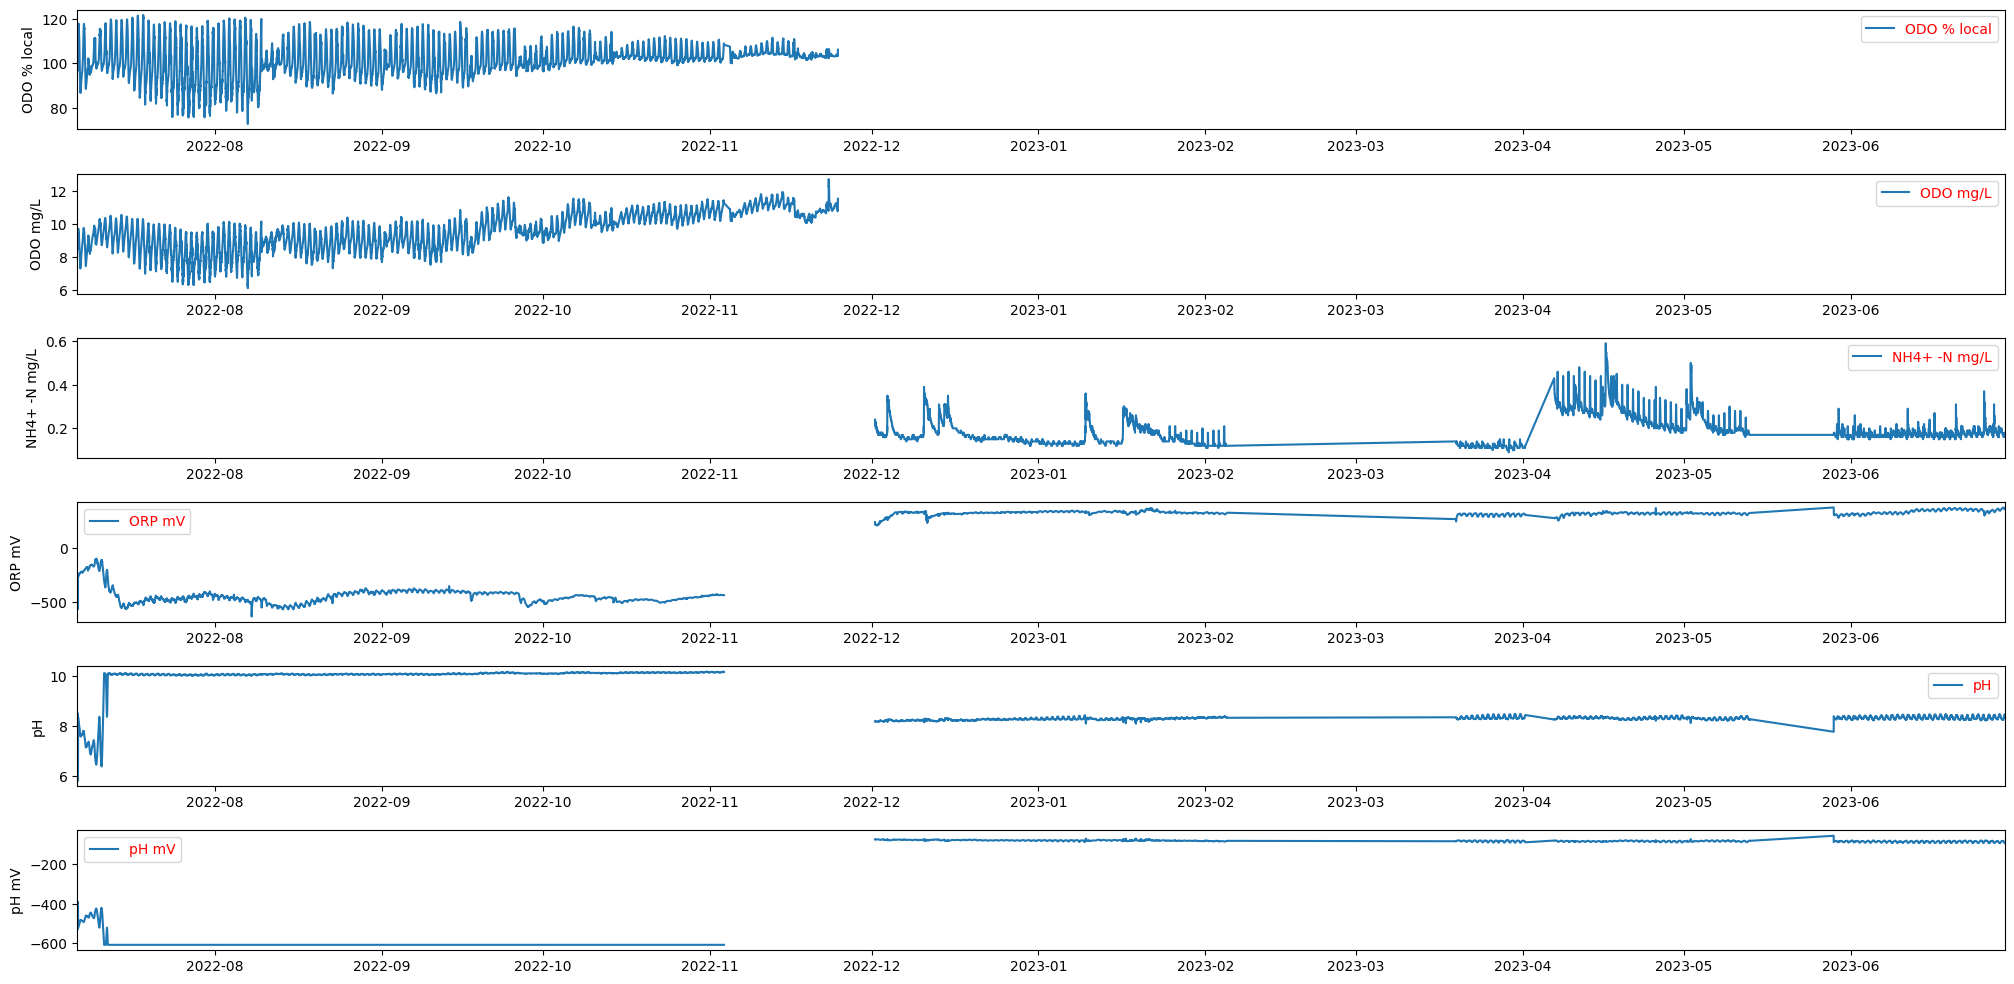

In [19]:
plot_columns(df_missing_data, columns_with_null[5:], figsize=(20,10))

### Remove Columns and Fill missing values

In [37]:
df.head()

,Date (MM/DD/YYYY),Time (HH:mm:ss),DateTime,Time (Fract,Sec),Site Name,NH3 mg/L,Cond µS/cm,fDOM QSU,NH4+ -N mV,...,SpCond µS/cm,TDS mg/L,Turbidity FNU,TSS mg/L,pH,pH mV,Temp °C,Battery V,Cable Pwr V,Wiper Position volt
65375,2022-07-06,07:50:00,2022-07-06 09:50:00+02:00,0,0,Turbolo,NaN,10.0,-6.44,NaN,...,10.7,7,94.28,0.0,7.39,-473.4,21.337,6.00,0.0,1.091
65376,2022-07-06,08:00:00,2022-07-06 10:00:00+02:00,0,0,Turbolo,NaN,510.4,18.30,NaN,...,560.4,364,18.72,0.0,7.43,-475.1,20.336,5.96,0.0,0.773
65377,2022-07-06,08:10:00,2022-07-06 10:10:00+02:00,0,0,Turbolo,NaN,511.8,19.81,NaN,...,561.9,365,7.02,0.0,7.70,-488.7,20.332,5.91,0.0,0.704
65378,2022-07-06,08:20:00,2022-07-06 10:20:00+02:00,0,0,Turbolo,NaN,511.9,19.85,NaN,...,562.3,365,6.31,0.0,8.43,-525.7,20.307,5.97,0.0,0.690
65379,2022-07-06,08:30:00,2022-07-06 10:30:00+02:00,0,0,Turbolo,NaN,510.3,20.03,NaN,...,559.6,364,3.87,0.0,8.41,-524.7,20.381,5.99,0.0,0.690


In [44]:
# df = Reader('dir/to/file')

df = df[df['DateTime'] > '2022-07-01 00:00:00']

unnecesary_parameters = ["Time (Fract", " Sec)"]
wrong_measures = ["NO3 -N mg/L", "NO3 -N mV", "NH4+ -N mg/L", "NH4+ -N mV"]
duplicated_measures = ["fDOM RFU", "pH mV"]

columns_to_delete = unnecesary_parameters + wrong_measures + duplicated_measures

df_clean = df.copy()
df_clean.drop(labels=columns_to_delete, axis=1, inplace=True)

ph_mean = df_clean[df_clean['pH'] < 8.5]['pH'].mean()

# fill null values
df_clean['ORP mV'] = df_clean['ORP mV'].fillna(df_clean['ORP mV'].mean())
df_clean['pH'] = df_clean['pH'].fillna(ph_mean)

# pH values greater or equal than 10 could be a device error
# let's fill pH values greater or equal than 10 with the mean of values less than 8.5
df_clean.loc[df_clean['pH'] >= 10, 'pH'] = ph_mean

In [21]:
unnecesary_parameters = ["Time (Fract", " Sec)"]
wrong_measures = ["NO3 -N mg/L", "NO3 -N mV", "NH4+ -N mg/L", "NH4+ -N mV"]
duplicated_measures = ["fDOM RFU", "pH mV"]

# do some analysis with parameters with too many missing values
too_many_missing_values = ["NH3 mg/L", "ODO % sat", "ODO % local", "ODO mg/L"]

columns_to_delete = unnecesary_parameters + wrong_measures + duplicated_measures + too_many_missing_values

df_clean = df.copy()
df_clean.drop(labels=columns_to_delete, axis=1, inplace=True)

# pH values greater or equal than 10 is a device error
# let's fill pH values greater or equal than 10 with the mean of values less than 8.5
ph_mean = df_clean[df_clean['pH'] < 8.5]['pH'].mean()
df_clean['pH'] = df_clean['pH'].fillna(ph_mean)
# df_clean.loc[df_clean['pH'] >= 10, 'pH'] = ph_mean
df_clean['ORP mV'] = df_clean['ORP mV'].fillna(df_clean['ORP mV'].mean())

df_clean.head(10)

,Date (MM/DD/YYYY),Time (HH:mm:ss),DateTime,Site Name,Cond µS/cm,fDOM QSU,nLF Cond µS/cm,ORP mV,Sal psu,SpCond µS/cm,TDS mg/L,Turbidity FNU,TSS mg/L,pH,Temp °C,Battery V,Cable Pwr V,Wiper Position volt
65375,2022-07-06,07:50:00,2022-07-06 09:50:00+02:00,Turbolo,10.0,-6.44,10.8,-235.5,0.00,10.7,7,94.28,0.0,7.39,21.337,6.00,0.0,1.091
65376,2022-07-06,08:00:00,2022-07-06 10:00:00+02:00,Turbolo,510.4,18.30,565.0,-273.6,0.27,560.4,364,18.72,0.0,7.43,20.336,5.96,0.0,0.773
65377,2022-07-06,08:10:00,2022-07-06 10:10:00+02:00,Turbolo,511.8,19.81,566.6,-297.1,0.27,561.9,365,7.02,0.0,7.70,20.332,5.91,0.0,0.704
65378,2022-07-06,08:20:00,2022-07-06 10:20:00+02:00,Turbolo,511.9,19.85,567.0,-327.2,0.27,562.3,365,6.31,0.0,8.43,20.307,5.97,0.0,0.690
65379,2022-07-06,08:30:00,2022-07-06 10:30:00+02:00,Turbolo,510.3,20.03,564.3,-326.7,0.27,559.6,364,3.87,0.0,8.41,20.381,5.99,0.0,0.690
65380,2022-07-06,08:40:00,2022-07-06 10:40:00+02:00,Turbolo,512.6,17.16,566.2,-327.3,0.27,561.6,365,27.21,0.0,8.30,20.429,5.99,0.0,0.690
65381,2022-07-06,08:50:00,2022-07-06 10:50:00+02:00,Turbolo,16.3,-6.42,17.8,-291.6,0.01,17.7,12,25.00,0.0,8.51,20.956,6.00,0.0,0.690
65382,2022-07-06,11:00:00,2022-07-06 13:00:00+02:00,Turbolo,3.9,-6.37,3.8,-566.1,0.00,3.8,2,17.28,0.0,5.80,26.161,5.96,0.0,0.683
65383,2022-07-06,11:10:00,2022-07-06 13:10:00+02:00,Turbolo,461.9,10.11,486.1,-242.3,0.23,483.9,315,16.91,0.0,7.68,22.625,5.95,0.0,1.081
65384,2022-07-06,11:20:00,2022-07-06 13:20:00+02:00,Turbolo,462.8,12.36,485.9,-269.1,0.23,483.8,314,0.80,0.0,8.31,22.732,5.99,0.0,0.831


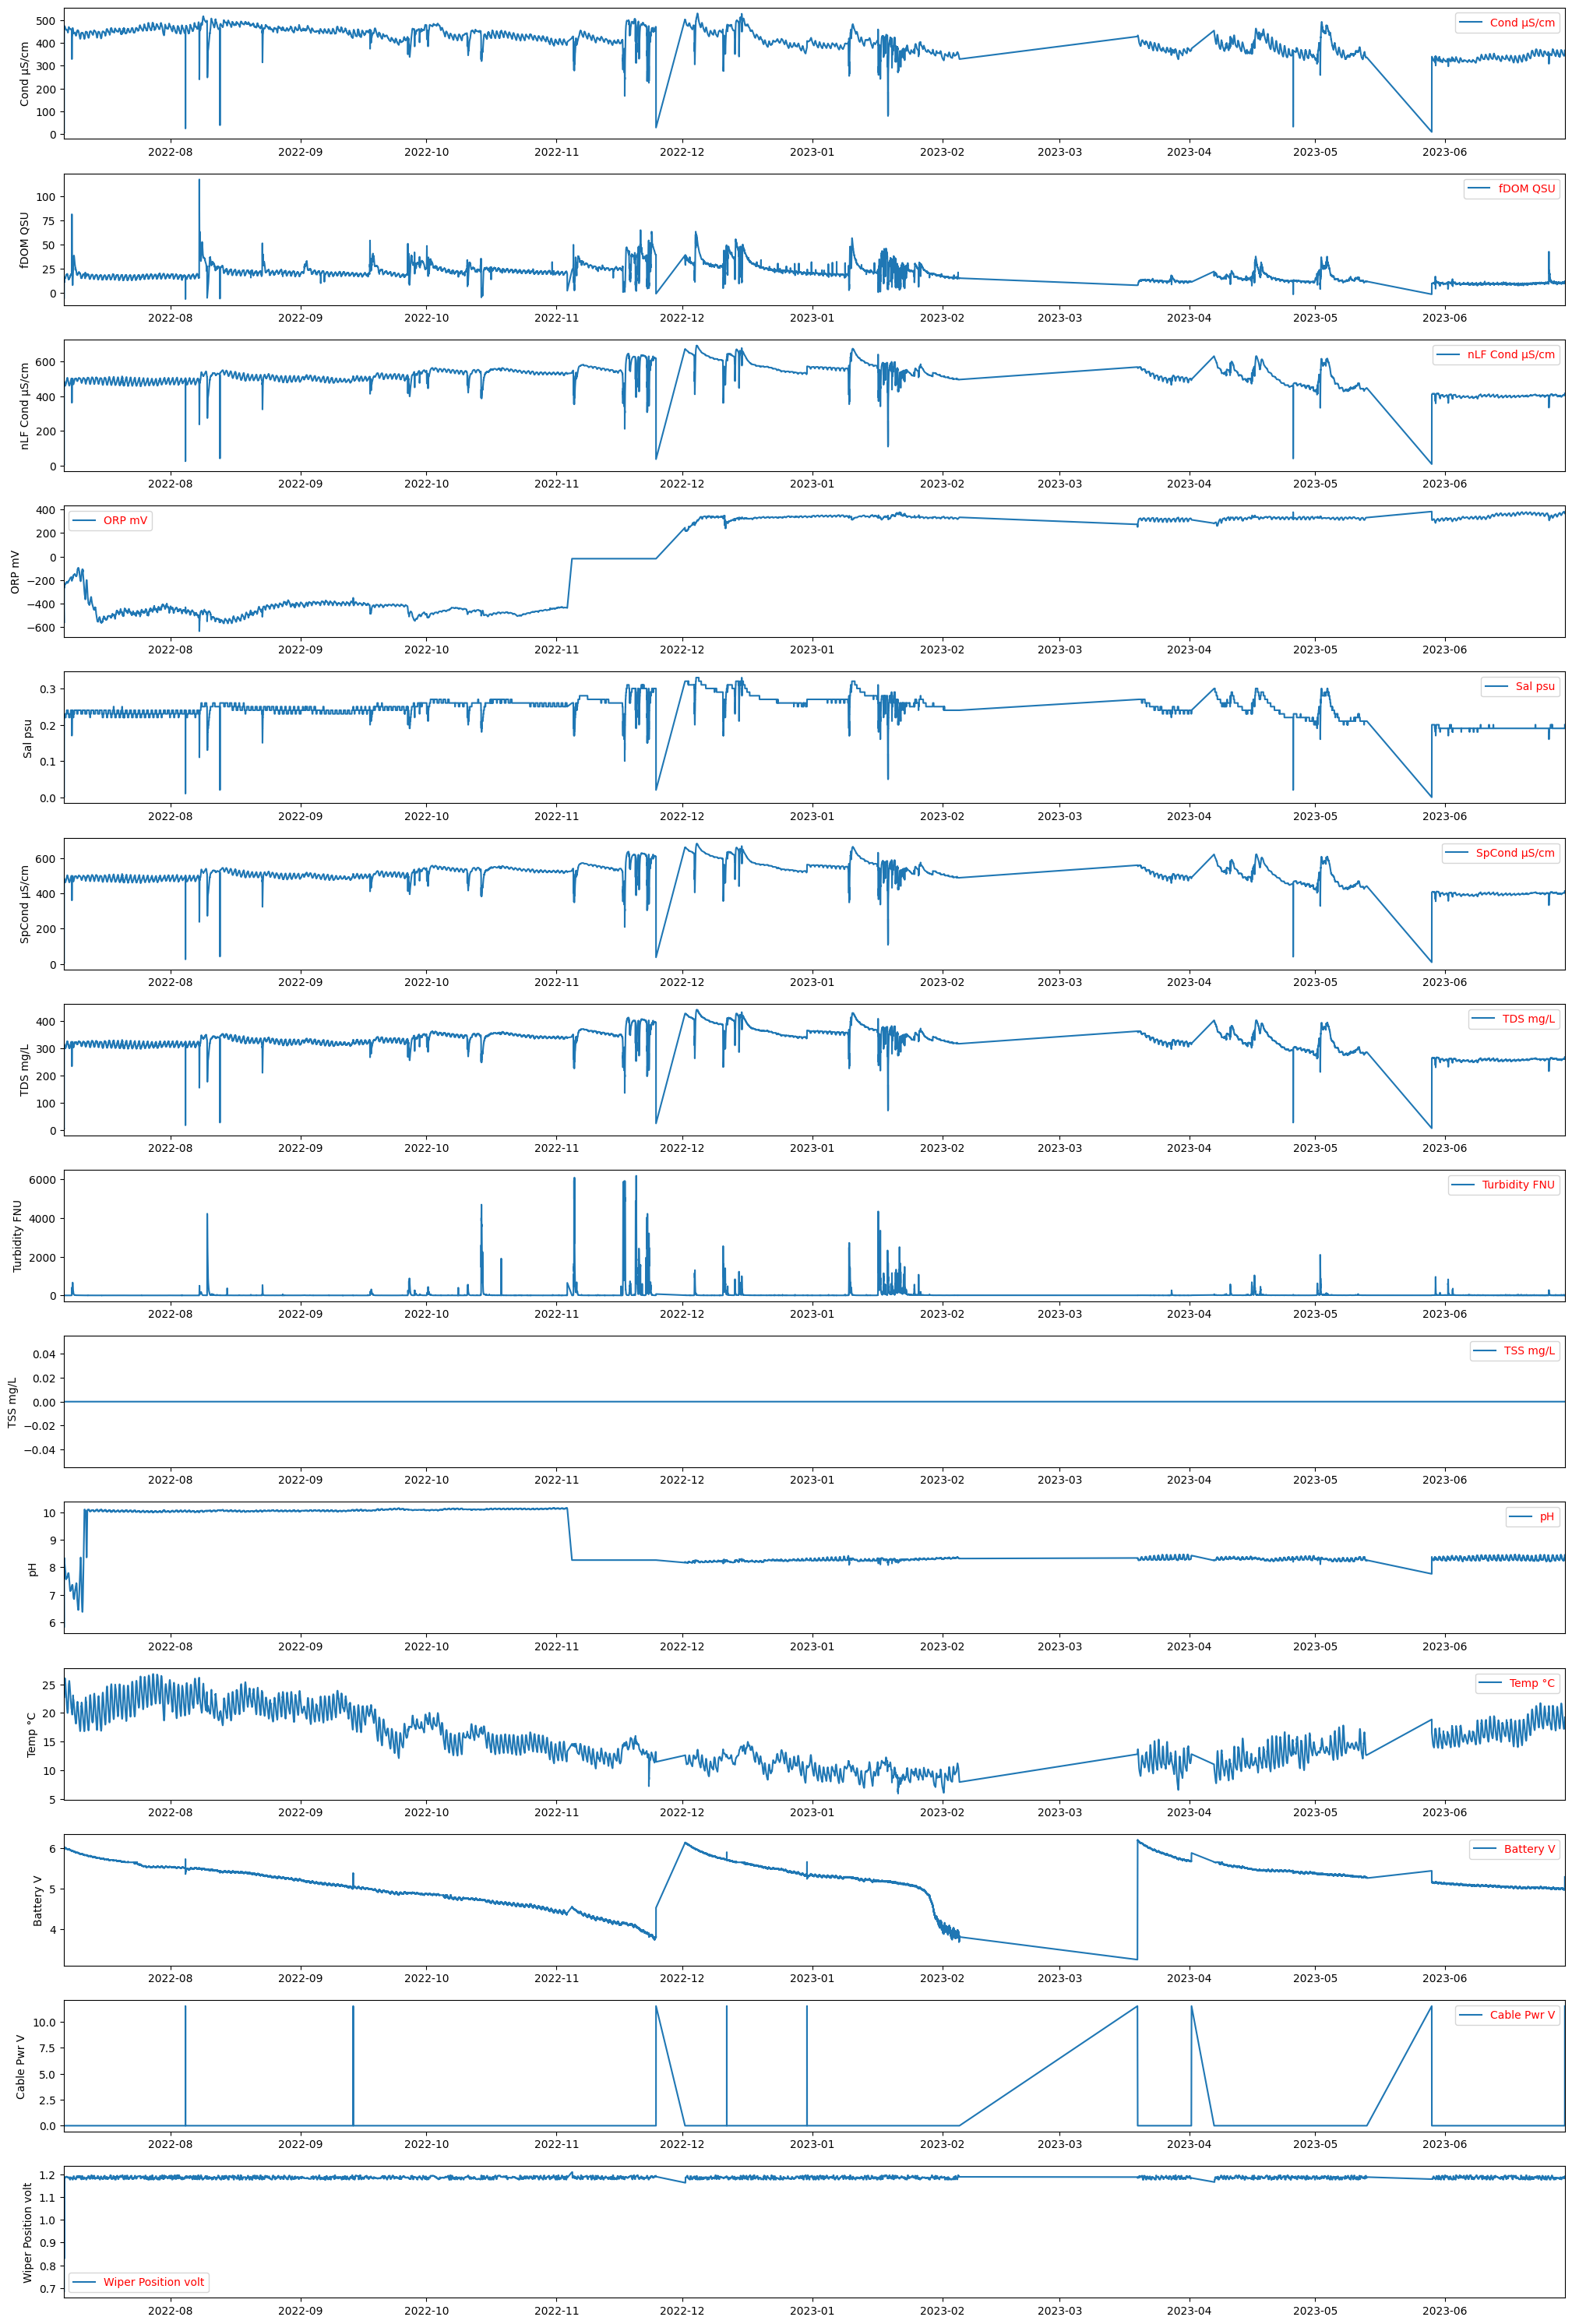

In [22]:
plot_columns(df_clean, df_clean.columns[4:])

In [23]:
df_clean['Turbidity FNU'].max()

6176.52

## Weather Data

In [42]:
df_weather.columns[3:]

Index(['Pioggia (mm)', 'Livello idrometrico (m)', 'Pressione hPa',
       'Radiazione solare W/mq', 'Temperatura (°C)', 'Umidità (%)',
       'Velocità vento (m/s)'],
      dtype='object')

In [24]:
weather_data_columns = df_weather.columns
df_weather[weather_data_columns[3:]] = df_weather[weather_data_columns[3:]].apply(pd.to_numeric, errors='coerce')
for c in weather_data_columns[3:]:
  df_weather[c] = df_weather[c].fillna(df_weather[c].mean())

In [25]:
df_weather.isna().sum()

Data                       0
Ora                        0
DateTime                   0
Pioggia (mm)               0
Livello idrometrico (m)    0
Pressione hPa              0
Radiazione solare W/mq     0
Temperatura (°C)           0
Umidità (%)                0
Velocità vento (m/s)       0
dtype: int64

In [26]:
df_weather.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
Data,8736,2023-01-29 12:00:00,2022-08-01 00:00:00,2022-10-30 18:00:00,2023-01-29 12:00:00,2023-04-30 06:00:00,2023-07-30 00:00:00,NaN
Pioggia (mm),8736.0,0.14736,0.0,0.0,0.0,0.0,31.0,0.85129
Livello idrometrico (m),8736.0,0.390551,0.26,0.34,0.38,0.42,1.06,0.07418
Pressione hPa,8736.0,995.336936,976.2,992.1,995.336936,998.4,1013.7,6.176913
Radiazione solare W/mq,8736.0,188.781806,0.0,0.0,0.0,323.0,1117.0,284.489615
Temperatura (°C),8736.0,16.162738,-3.4,10.5,15.5,21.3,41.7,7.973837
Umidità (%),8736.0,73.387633,14.0,56.0,75.0,96.0,100.0,22.075966
Velocità vento (m/s),8736.0,3.461753,0.0,1.6,2.3,4.4,22.7,2.856882


In [27]:
df_weather.head(10)

,Data,Ora,DateTime,Pioggia (mm),Livello idrometrico (m),Pressione hPa,Radiazione solare W/mq,Temperatura (°C),Umidità (%),Velocità vento (m/s)
0,2022-08-01,00:00:00,2022-08-01 02:00:00+02:00,0.0,0.32,995.336936,0.0,18.8,85.0,1.2
1,2022-08-01,01:00:00,2022-08-01 03:00:00+02:00,0.0,0.33,995.336936,0.0,18.1,85.0,1.7
2,2022-08-01,02:00:00,2022-08-01 04:00:00+02:00,0.0,0.33,995.336936,0.0,18.1,84.0,1.9
3,2022-08-01,03:00:00,2022-08-01 05:00:00+02:00,0.0,0.33,995.336936,0.0,17.0,91.0,1.4
4,2022-08-01,04:00:00,2022-08-01 06:00:00+02:00,0.0,0.33,995.336936,0.0,16.3,93.0,1.5
5,2022-08-01,05:00:00,2022-08-01 07:00:00+02:00,0.0,0.33,995.336936,0.0,16.0,94.0,1.6
6,2022-08-01,06:00:00,2022-08-01 08:00:00+02:00,0.0,0.34,995.336936,124.0,17.9,86.0,1.0
7,2022-08-01,07:00:00,2022-08-01 09:00:00+02:00,0.0,0.32,995.336936,325.0,24.6,57.0,1.9
8,2022-08-01,08:00:00,2022-08-01 10:00:00+02:00,0.0,0.32,995.336936,532.0,27.6,48.0,1.9
9,2022-08-01,09:00:00,2022-08-01 11:00:00+02:00,0.0,0.34,995.336936,717.0,29.7,35.0,3.0


# Merge Sensor and Weather Data

In [28]:
merged = pd.merge_ordered(df_clean, df_weather, fill_method="ffill", on="DateTime")

In [29]:
merged[merged['Ora'].notnull()].head(10)

,Date (MM/DD/YYYY),Time (HH:mm:ss),DateTime,Site Name,Cond µS/cm,fDOM QSU,nLF Cond µS/cm,ORP mV,Sal psu,SpCond µS/cm,...,Wiper Position volt,Data,Ora,Pioggia (mm),Livello idrometrico (m),Pressione hPa,Radiazione solare W/mq,Temperatura (°C),Umidità (%),Velocità vento (m/s)
3685,2022-08-01,00:00:00,2022-08-01 02:00:00+02:00,Turbolo,463.4,18.34,482.2,-434.9,0.23,480.5,...,1.196,2022-08-01,00:00:00,0.0,0.32,995.336936,0.0,18.8,85.0,1.2
3686,2022-08-01,00:10:00,2022-08-01 02:10:00+02:00,Turbolo,462.8,18.45,482.4,-435.4,0.23,480.6,...,1.196,2022-08-01,00:00:00,0.0,0.32,995.336936,0.0,18.8,85.0,1.2
3687,2022-08-01,00:20:00,2022-08-01 02:20:00+02:00,Turbolo,462.5,18.48,482.8,-435.8,0.23,481.0,...,1.196,2022-08-01,00:00:00,0.0,0.32,995.336936,0.0,18.8,85.0,1.2
3688,2022-08-01,00:30:00,2022-08-01 02:30:00+02:00,Turbolo,462.1,18.54,483.3,-435.9,0.23,481.4,...,1.196,2022-08-01,00:00:00,0.0,0.32,995.336936,0.0,18.8,85.0,1.2
3689,2022-08-01,00:40:00,2022-08-01 02:40:00+02:00,Turbolo,461.6,18.65,483.7,-436.4,0.23,481.8,...,1.196,2022-08-01,00:00:00,0.0,0.32,995.336936,0.0,18.8,85.0,1.2
3690,2022-08-01,00:50:00,2022-08-01 02:50:00+02:00,Turbolo,461.4,18.56,484.2,-436.7,0.23,482.1,...,1.196,2022-08-01,00:00:00,0.0,0.32,995.336936,0.0,18.8,85.0,1.2
3691,2022-08-01,01:00:00,2022-08-01 03:00:00+02:00,Turbolo,461.1,18.63,484.5,-437.3,0.23,482.4,...,1.196,2022-08-01,01:00:00,0.0,0.33,995.336936,0.0,18.1,85.0,1.7
3692,2022-08-01,01:10:00,2022-08-01 03:10:00+02:00,Turbolo,460.7,18.75,484.8,-437.8,0.23,482.7,...,1.196,2022-08-01,01:00:00,0.0,0.33,995.336936,0.0,18.1,85.0,1.7
3693,2022-08-01,01:20:00,2022-08-01 03:20:00+02:00,Turbolo,460.2,18.75,485.2,-439.2,0.23,482.9,...,1.196,2022-08-01,01:00:00,0.0,0.33,995.336936,0.0,18.1,85.0,1.7
3694,2022-08-01,01:30:00,2022-08-01 03:30:00+02:00,Turbolo,459.8,18.86,485.7,-441.0,0.23,483.4,...,1.196,2022-08-01,01:00:00,0.0,0.33,995.336936,0.0,18.1,85.0,1.7


In [30]:
len(merged[merged['Date (MM/DD/YYYY)']< '2022-08-01'])

3685

In [31]:
merged[merged['Date (MM/DD/YYYY)'] > '08/20/2022'].head(20)

,Date (MM/DD/YYYY),Time (HH:mm:ss),DateTime,Site Name,Cond µS/cm,fDOM QSU,nLF Cond µS/cm,ORP mV,Sal psu,SpCond µS/cm,...,Wiper Position volt,Data,Ora,Pioggia (mm),Livello idrometrico (m),Pressione hPa,Radiazione solare W/mq,Temperatura (°C),Umidità (%),Velocità vento (m/s)
6565,2022-08-21,00:00:00,2022-08-21 02:00:00+02:00,Turbolo,473.3,21.00,504.9,-469.0,0.24,502.1,...,1.196,2022-08-21,00:00:00,0.0,0.32,995.336936,0.0,21.0,76.0,1.8
6566,2022-08-21,00:10:00,2022-08-21 02:10:00+02:00,Turbolo,473.3,21.13,505.5,-469.0,0.24,502.6,...,1.196,2022-08-21,00:00:00,0.0,0.32,995.336936,0.0,21.0,76.0,1.8
6567,2022-08-21,00:20:00,2022-08-21 02:20:00+02:00,Turbolo,473.2,21.21,505.9,-468.9,0.24,503.0,...,1.196,2022-08-21,00:00:00,0.0,0.32,995.336936,0.0,21.0,76.0,1.8
6568,2022-08-21,00:30:00,2022-08-21 02:30:00+02:00,Turbolo,471.6,21.38,504.8,-468.3,0.24,501.9,...,1.196,2022-08-21,00:00:00,0.0,0.32,995.336936,0.0,21.0,76.0,1.8
6569,2022-08-21,00:40:00,2022-08-21 02:40:00+02:00,Turbolo,472.0,21.17,506.0,-467.7,0.24,503.0,...,1.188,2022-08-21,00:00:00,0.0,0.32,995.336936,0.0,21.0,76.0,1.8
6570,2022-08-21,00:50:00,2022-08-21 02:50:00+02:00,Turbolo,471.8,21.38,506.3,-468.2,0.24,503.3,...,1.188,2022-08-21,00:00:00,0.0,0.32,995.336936,0.0,21.0,76.0,1.8
6571,2022-08-21,01:00:00,2022-08-21 03:00:00+02:00,Turbolo,472.6,21.38,507.7,-468.4,0.24,504.6,...,1.188,2022-08-21,01:00:00,0.0,0.32,995.336936,0.0,19.9,81.0,1.4
6572,2022-08-21,01:10:00,2022-08-21 03:10:00+02:00,Turbolo,471.3,21.41,507.0,-469.3,0.24,503.9,...,1.188,2022-08-21,01:00:00,0.0,0.32,995.336936,0.0,19.9,81.0,1.4
6573,2022-08-21,01:20:00,2022-08-21 03:20:00+02:00,Turbolo,472.5,21.39,509.1,-469.2,0.24,505.9,...,1.188,2022-08-21,01:00:00,0.0,0.32,995.336936,0.0,19.9,81.0,1.4
6574,2022-08-21,01:30:00,2022-08-21 03:30:00+02:00,Turbolo,472.2,21.49,509.4,-469.4,0.24,506.2,...,1.188,2022-08-21,01:00:00,0.0,0.32,995.336936,0.0,19.9,81.0,1.4


In [32]:
merged.columns

Index(['Date (MM/DD/YYYY)', 'Time (HH:mm:ss)', 'DateTime', 'Site Name',
       'Cond µS/cm', 'fDOM QSU', 'nLF Cond µS/cm', 'ORP mV', 'Sal psu',
       'SpCond µS/cm', 'TDS mg/L', 'Turbidity FNU', 'TSS mg/L', 'pH',
       'Temp °C', 'Battery V', 'Cable Pwr V', 'Wiper Position volt', 'Data',
       'Ora', 'Pioggia (mm)', 'Livello idrometrico (m)', 'Pressione hPa',
       'Radiazione solare W/mq', 'Temperatura (°C)', 'Umidità (%)',
       'Velocità vento (m/s)'],
      dtype='object')

In [33]:
merged.head()

,Date (MM/DD/YYYY),Time (HH:mm:ss),DateTime,Site Name,Cond µS/cm,fDOM QSU,nLF Cond µS/cm,ORP mV,Sal psu,SpCond µS/cm,...,Wiper Position volt,Data,Ora,Pioggia (mm),Livello idrometrico (m),Pressione hPa,Radiazione solare W/mq,Temperatura (°C),Umidità (%),Velocità vento (m/s)
0,2022-07-06,07:50:00,2022-07-06 09:50:00+02:00,Turbolo,10.0,-6.44,10.8,-235.5,0.00,10.7,...,1.091,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-07-06,08:00:00,2022-07-06 10:00:00+02:00,Turbolo,510.4,18.30,565.0,-273.6,0.27,560.4,...,0.773,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-07-06,08:10:00,2022-07-06 10:10:00+02:00,Turbolo,511.8,19.81,566.6,-297.1,0.27,561.9,...,0.704,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-07-06,08:20:00,2022-07-06 10:20:00+02:00,Turbolo,511.9,19.85,567.0,-327.2,0.27,562.3,...,0.690,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-07-06,08:30:00,2022-07-06 10:30:00+02:00,Turbolo,510.3,20.03,564.3,-326.7,0.27,559.6,...,0.690,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# plot_columns(merged, merged.columns[20:])

In [35]:
# plt.figure(figsize=(20,15))
# sns.heatmap(merged.corr(), annot=True, vmin=-1, vmax=1)

# Save preproced data

In [36]:
# df_clean.describe()
df_weather.describe()
# df_clean.to_csv("sensors_clean.csv")
# df_weather.to_csv("weather.csv")
# merged.to_csv("merged_sensors_weather.csv")

,Data,Pioggia (mm),Livello idrometrico (m),Pressione hPa,Radiazione solare W/mq,Temperatura (°C),Umidità (%),Velocità vento (m/s)
count,8736,8736.00000,8736.000000,8736.000000,8736.000000,8736.000000,8736.000000,8736.000000
mean,2023-01-29 12:00:00,0.14736,0.390551,995.336936,188.781806,16.162738,73.387633,3.461753
min,2022-08-01 00:00:00,0.00000,0.260000,976.200000,0.000000,-3.400000,14.000000,0.000000
25%,2022-10-30 18:00:00,0.00000,0.340000,992.100000,0.000000,10.500000,56.000000,1.600000
50%,2023-01-29 12:00:00,0.00000,0.380000,995.336936,0.000000,15.500000,75.000000,2.300000
75%,2023-04-30 06:00:00,0.00000,0.420000,998.400000,323.000000,21.300000,96.000000,4.400000
max,2023-07-30 00:00:00,31.00000,1.060000,1013.700000,1117.000000,41.700000,100.000000,22.700000
std,NaN,0.85129,0.074180,6.176913,284.489615,7.973837,22.075966,2.856882


In [38]:
merged.columns

Index(['Date (MM/DD/YYYY)', 'Time (HH:mm:ss)', 'DateTime', 'Site Name',
       'Cond µS/cm', 'fDOM QSU', 'nLF Cond µS/cm', 'ORP mV', 'Sal psu',
       'SpCond µS/cm', 'TDS mg/L', 'Turbidity FNU', 'TSS mg/L', 'pH',
       'Temp °C', 'Battery V', 'Cable Pwr V', 'Wiper Position volt', 'Data',
       'Ora', 'Pioggia (mm)', 'Livello idrometrico (m)', 'Pressione hPa',
       'Radiazione solare W/mq', 'Temperatura (°C)', 'Umidità (%)',
       'Velocità vento (m/s)'],
      dtype='object')

# Model

In [ ]:
df_for_model = df_clean.copy().loc[:, ['fDOM QSU', 'Temp °C', 'Turbidity FNU', 'pH', 'Cond µS/cm', 'ORP mV']]
print(len(df_for_model))
print(len(df_for_model))
df_for_model.head()
df_for_model.head()

41285
41285


,fDOM QSU,Temp °C,Turbidity FNU,pH,Cond µS/cm,ORP mV
65375,-6.44,21.337,94.28,7.39,10.0,-235.5
65376,18.30,20.336,18.72,7.43,510.4,-273.6
65377,19.81,20.332,7.02,7.70,511.8,-297.1
65378,19.85,20.307,6.31,8.43,511.9,-327.2
65379,20.03,20.381,3.87,8.41,510.3,-326.7


Index(['Date (MM/DD/YYYY)', 'Time (HH:mm:ss)', 'DateTime', 'Site Name',
       'Cond µS/cm', 'fDOM QSU', 'nLF Cond µS/cm', 'ORP mV', 'Sal psu',
       'SpCond µS/cm', 'TDS mg/L', 'Turbidity FNU', 'TSS mg/L', 'pH',
       'Temp °C', 'Battery V', 'Cable Pwr V', 'Wiper Position volt'],
      dtype='object')


<Axes: >

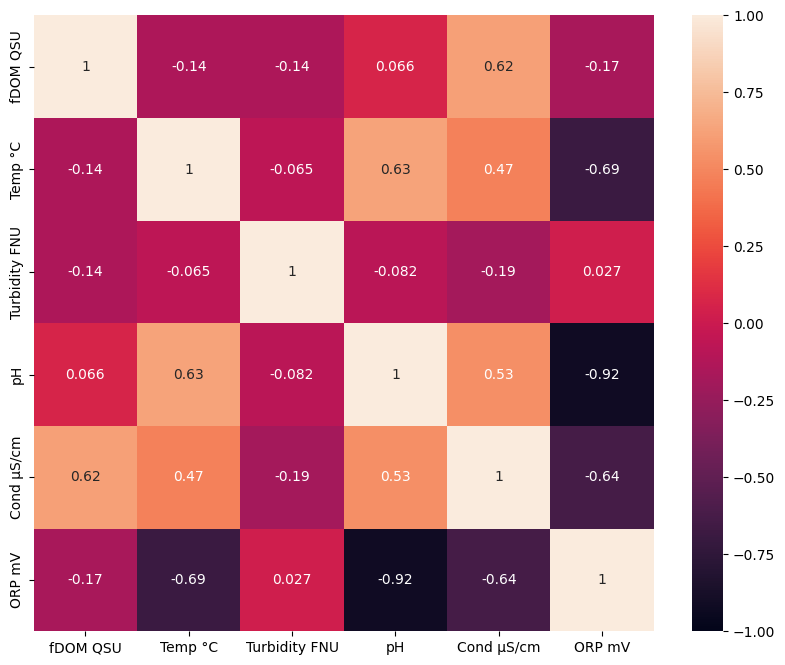

In [ ]:
print(df_clean.columns)
plt.figure(figsize=(10,8))
# pH and ORP mV are measured by the same sensor
sns.heatmap(df_for_model.corr(), annot=True, vmin=-1, vmax=1)

In [ ]:
df_for_model.isna().sum()
# df_for_model.describe()

fDOM QSU         0
Temp °C          0
Turbidity FNU    0
pH               0
Cond µS/cm       0
ORP mV           0
dtype: int64

In [ ]:
df_for_model = df_for_model.copy().loc[:, ['Temp °C', 'fDOM QSU', 'Cond µS/cm', 'pH', 'ORP mV']]
train_dataset = df_for_model.sample(frac=0.8, random_state=0)
test_dataset = df_for_model.drop(train_dataset.index)

In [ ]:
train_dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Temp °C,33028.0,15.370943,4.540160,5.959,11.682000,14.583,19.008,26.792
fDOM QSU,33028.0,20.263360,8.560405,-6.830,14.290000,19.530,23.990,117.860
Cond µS/cm,33028.0,412.228588,51.103656,3.900,369.100000,418.900,453.700,530.200
pH,33028.0,8.992292,0.903168,5.800,8.263183,8.340,10.070,10.170
ORP mV,33028.0,-17.891079,375.697778,-636.000,-440.500000,285.900,332.700,383.100


In [ ]:
train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop('pH')
test_labels = test_features.pop('pH')

In [ ]:
train_dataset.describe().transpose()[['mean', 'std']]

,mean,std
Temp °C,15.370943,4.540160
fDOM QSU,20.263360,8.560405
Cond µS/cm,412.228588,51.103656
pH,8.992292,0.903168
ORP mV,-17.891079,375.697778


In [ ]:
normalizer = tf.keras.layers.Normalization(input_shape=[4,], axis=None)
normalizer.adapt(np.array(train_features))

In [ ]:
def build_and_compile_model(norm):
  model = Sequential([
      norm,
      Dense(64, activation='relu'),
      Dense(64, activation='relu'),
      Dense(1)
  ])

  model.compile(loss='mean_absolute_error',
                optimizer=tf.keras.optimizers.Adam(0.001))
  return model

In [ ]:
model = build_and_compile_model(normalizer)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization (Normalizati  (None, 4)                 3         
 on)                                                             
                                                                 
 dense (Dense)               (None, 64)                320       
                                                                 
 dense_1 (Dense)             (None, 64)                4160      
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 4548 (17.77 KB)
Trainable params: 4545 (17.75 KB)
Non-trainable params: 3 (16.00 Byte)
_________________________________________________________________


In [ ]:
%%time
history = model.fit(
    train_features,
    train_labels,
    validation_split=0.2,
    verbose=0, epochs=100)

CPU times: user 3min 33s, sys: 8.76 s, total: 3min 42s
Wall time: 3min 43s


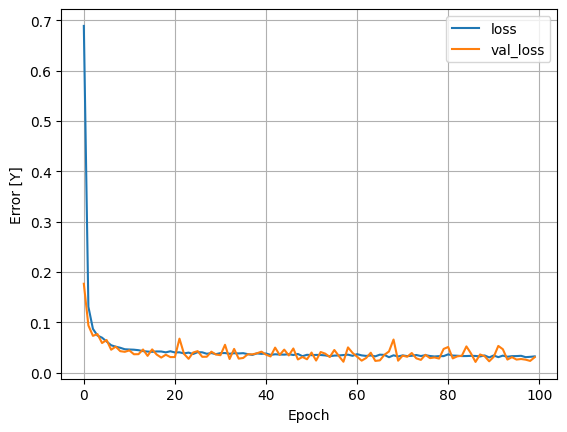

In [ ]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  # plt.ylim([0, 10])
  plt.xlabel('Epoch')
  plt.ylabel('Error [Y]')
  plt.legend()
  plt.grid(True)

plot_loss(history)

In [ ]:
model.evaluate(test_features, test_labels, verbose=0)

0.030685139819979668

In [ ]:
test_predictions = model.predict(test_features).flatten()

259/259 [==============================] - 1s 3ms/step


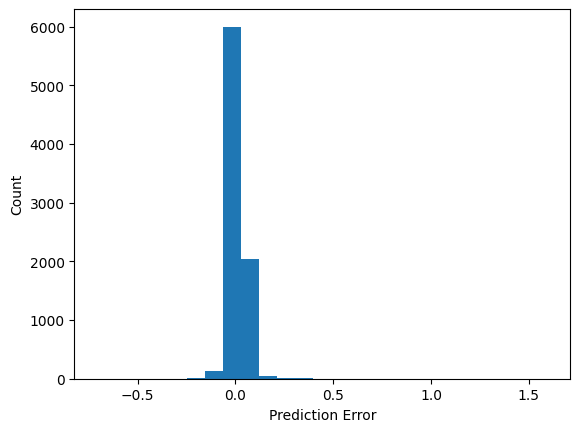

In [ ]:
error = test_predictions - test_labels
plt.hist(error, bins=25)
plt.xlabel('Prediction Error')
_ = plt.ylabel('Count')

In [ ]:
df_for_model.head()

,Temp °C,fDOM QSU,Cond µS/cm,pH,ORP mV
65375,21.337,-6.44,10.0,7.39,-235.5
65376,20.336,18.30,510.4,7.43,-273.6
65377,20.332,19.81,511.8,7.70,-297.1
65378,20.307,19.85,511.9,8.43,-327.2
65379,20.381,20.03,510.3,8.41,-326.7


In [ ]:
model.predict(np.array([21.33, -6.66, 10, -235.5]))

1/1 [==============================] - 0s 102ms/step


array([[8.353346]], dtype=float32)